# Player Reception vs. Critic Score: Steam Game Divergence Analysis

This notebook uses the 5 cleaned CSVs under `Cleaned_Data/` and performs **pure descriptive analytics** (no machine learning) to answer one question:

> Where do Steam player ratings (`review_score` / positive ratio) and critic ratings (`metacritic_score`) systematically disagree — across titles, genres, publishers, price tiers, and years?

Table of contents:

0. **Setup** — data loading and merging
1. **Metric construction & marginal distributions**
2. **Consistency & correlation**
3. **Four-quadrant split** — Both Loved / Player-Favored / Critic-Favored / Both Disliked
4. **Most under-rated / over-rated title lists**
5. **Slice by genre**
6. **Slice by category & tag**
7. **Slice by publisher / developer**
8. **Slice by price / free vs paid / owners range**
9. **Trend by release year**
10. **Divergence vs review volume**
11. **Summary**

## Section 0 — Setup

Import dependencies, define CONFIG, load the 5 cleaned CSVs and merge them to build the core analysis sample.

In [15]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["axes.unicode_minus"] = False
for _font in ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]:
    plt.rcParams["font.sans-serif"] = [_font]
    break

DATA_DIR = Path("Cleaned_Data")

CONFIG = {
    "min_total_reviews": 10,       # minimum player-review count to suppress small-sample noise
    "player_love_threshold": 0.80, # positive ratio >= 80%  -> "players love it"
    "critic_love_threshold": 75,   # metacritic    >= 75    -> "critics love it"
    "min_games_per_genre": 20,     # minimum games per genre for the genre aggregation
    "min_games_per_category": 20,
    "min_games_per_publisher": 5,
    "min_games_per_developer": 5,
    "top_n": 15,
}
CONFIG

{'min_total_reviews': 10,
 'player_love_threshold': 0.8,
 'critic_love_threshold': 75,
 'min_games_per_genre': 20,
 'min_games_per_category': 20,
 'min_games_per_publisher': 5,
 'min_games_per_developer': 5,
 'top_n': 15}

In [16]:
reviews = pd.read_csv(DATA_DIR / "reviews_clean.csv")
games   = pd.read_csv(DATA_DIR / "games_clean.csv")
genres_long     = pd.read_csv(DATA_DIR / "genres_clean.csv")
tags_long       = pd.read_csv(DATA_DIR / "tags_clean.csv")
categories_long = pd.read_csv(DATA_DIR / "categories_clean.csv")

print(f"reviews       : {reviews.shape}")
print(f"games         : {games.shape}")
print(f"genres_long   : {genres_long.shape}")
print(f"tags_long     : {tags_long.shape}")
print(f"categories    : {categories_long.shape}")

OWNERS_ORDER = [
    "0 .. 20,000",
    "20,000 .. 50,000",
    "50,000 .. 100,000",
    "100,000 .. 200,000",
    "200,000 .. 500,000",
    "500,000 .. 1,000,000",
    "1,000,000 .. 2,000,000",
    "2,000,000 .. 5,000,000",
    "5,000,000 .. 10,000,000",
    "10,000,000 .. 20,000,000",
    "20,000,000 .. 50,000,000",
    "50,000,000 .. 100,000,000",
    "100,000,000 .. 200,000,000",
]

games = games.copy()
games["release_date"] = pd.to_datetime(games["release_date"], errors="coerce")
games["release_year"] = games["release_date"].dt.year
games["owners_range"] = pd.Categorical(
    games["owners_range"],
    categories=[c for c in OWNERS_ORDER if c in set(games["owners_range"].dropna().unique())],
    ordered=True,
)
games["is_free"] = games["is_free"].astype("Int64")
games.head(3)

reviews       : (140082, 10)
games         : (140082, 8)
genres_long   : (353339, 2)
tags_long     : (1744632, 2)
categories    : (522569, 2)


,app_id,name,release_date,is_free,developer,publisher,owners_range,price,release_year
0,10,Counter-Strike,2000-11-01,0,Valve,Valve,"10,000,000 .. 20,000,000",9.99,2000.0
1,20,Team Fortress Classic,1999-04-01,0,Valve,Valve,"5,000,000 .. 10,000,000",4.99,1999.0
2,30,Day of Defeat,2003-05-01,0,Valve,Valve,"5,000,000 .. 10,000,000",4.99,2003.0


In [17]:
df = reviews.merge(games, on="app_id", how="left")

n_raw = len(df)
n_has_metacritic = df["metacritic_score"].notna().sum()

core = df[df["metacritic_score"].notna() & (df["total"] >= CONFIG["min_total_reviews"])].copy()

report = pd.DataFrame(
    {
        "stage": [
            "Raw reviews rows",
            "Has metacritic_score",
            f"And total >= {CONFIG['min_total_reviews']} (core analysis sample)",
        ],
        "rows": [n_raw, int(n_has_metacritic), len(core)],
    }
)
report["pct_of_raw"] = (report["rows"] / n_raw * 100).round(2).astype(str) + "%"
report

,stage,rows,pct_of_raw
0,Raw reviews rows,140082,100.0%
1,Has metacritic_score,4745,3.39%
2,And total >= 10 (core analysis sample),4155,2.97%


## Section 1 — Metric construction & marginal distributions

To make the two yardsticks comparable, we put both the player side and the critic side on the same 0-100 scale:

- `player_ratio = positive / total` (finest-grained positive ratio, 0-1)
- `player_ratio_100 = player_ratio * 100` (rescaled to 0-100)
- `player_norm = review_score / 9 * 100` (Steam's aggregate score normalised)
- `critic_norm = metacritic_score` (already 0-100)

Divergence definition: **positive = players love it more than critics; negative = critics love it more than players**

- `divergence_ratio = player_ratio_100 - critic_norm` (primary metric, based on raw positive ratio)
- `divergence_steam = player_norm - critic_norm` (secondary metric, based on Steam's aggregate tier)

In [18]:
core["player_ratio"]     = core["positive"] / core["total"]
core["player_ratio_100"] = core["player_ratio"] * 100
core["player_norm"]      = core["review_score"] / 9 * 100
core["critic_norm"]      = core["metacritic_score"].astype(float)
core["divergence_ratio"] = core["player_ratio_100"] - core["critic_norm"]
core["divergence_steam"] = core["player_norm"]      - core["critic_norm"]

core[[
    "player_ratio_100", "player_norm", "critic_norm",
    "divergence_ratio", "divergence_steam",
]].describe().round(2)

,player_ratio_100,player_norm,critic_norm,divergence_ratio,divergence_steam
count,4155.00,4155.00,4155.00,4155.00,4155.00
mean,80.50,78.25,73.57,6.93,4.68
std,14.11,15.34,10.30,11.47,12.93
min,10.00,11.11,20.00,-63.26,-53.78
25%,73.30,66.67,68.00,1.02,-4.33
50%,83.97,88.89,75.00,8.16,6.89
75%,91.26,88.89,81.00,14.05,13.89
max,100.00,100.00,97.00,47.85,53.89


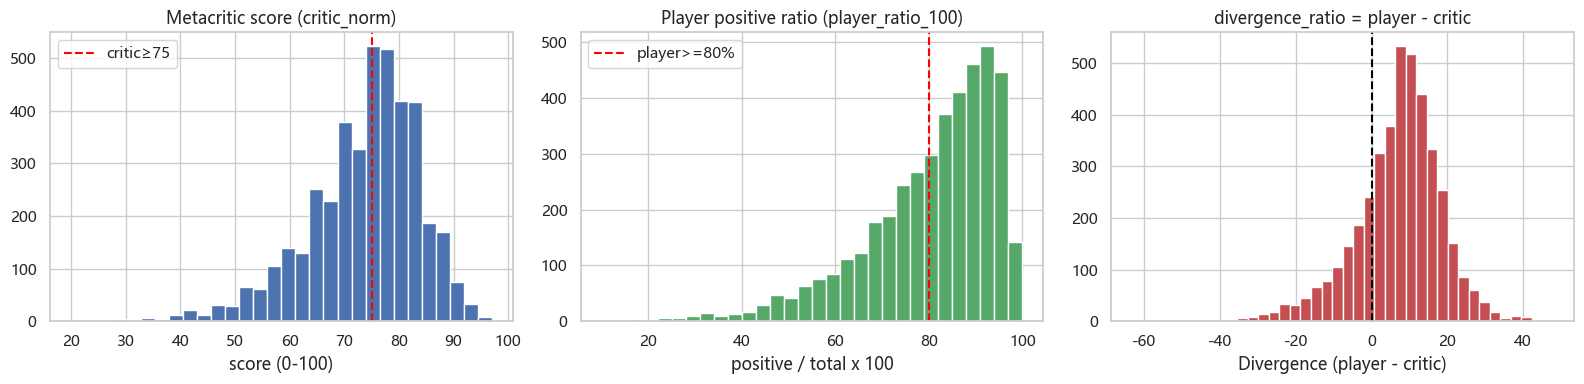

review_score_description distribution (within core sample):
review_score_description
Very Positive              2090
Mostly Positive             788
Mixed                       767
Overwhelmingly Positive     311
Positive                    134
Mostly Negative              58
Overwhelmingly Negative       4
Very Negative                 2
Negative                      1
Name: count, dtype: int64


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(core["critic_norm"], bins=30, color="#4C72B0", edgecolor="white")
axes[0].axvline(CONFIG["critic_love_threshold"], color="red", linestyle="--", label=f"critic≥{CONFIG['critic_love_threshold']}")
axes[0].set_title("Metacritic score (critic_norm)")
axes[0].set_xlabel("score (0-100)")
axes[0].legend()

axes[1].hist(core["player_ratio_100"], bins=30, color="#55A868", edgecolor="white")
axes[1].axvline(CONFIG["player_love_threshold"] * 100, color="red", linestyle="--", label=f"player>={int(CONFIG['player_love_threshold']*100)}%")
axes[1].set_title("Player positive ratio (player_ratio_100)")
axes[1].set_xlabel("positive / total x 100")
axes[1].legend()

axes[2].hist(core["divergence_ratio"], bins=40, color="#C44E52", edgecolor="white")
axes[2].axvline(0, color="black", linestyle="--")
axes[2].set_title("divergence_ratio = player - critic")
axes[2].set_xlabel("Divergence (player - critic)")

plt.tight_layout()
plt.show()

desc_counts = core["review_score_description"].value_counts()
print("review_score_description distribution (within core sample):")
print(desc_counts)

## Section 2 — Consistency & correlation

How aligned are players and critics overall? We use Pearson / Spearman correlations plus a scatter plot with a 45° reference line and a binned-mean curve.

In [20]:
corrs = pd.DataFrame(
    {
        "pair": [
            "player_ratio_100  vs  critic_norm",
            "player_norm       vs  critic_norm",
        ],
        "pearson": [
            core[["player_ratio_100", "critic_norm"]].corr().iloc[0, 1],
            core[["player_norm",      "critic_norm"]].corr().iloc[0, 1],
        ],
        "spearman": [
            core[["player_ratio_100", "critic_norm"]].corr(method="spearman").iloc[0, 1],
            core[["player_norm",      "critic_norm"]].corr(method="spearman").iloc[0, 1],
        ],
    }
)
corrs.round(3)

,pair,pearson,spearman
0,player_ratio_100 vs critic_norm,0.597,0.576
1,player_norm vs critic_norm,0.551,0.540


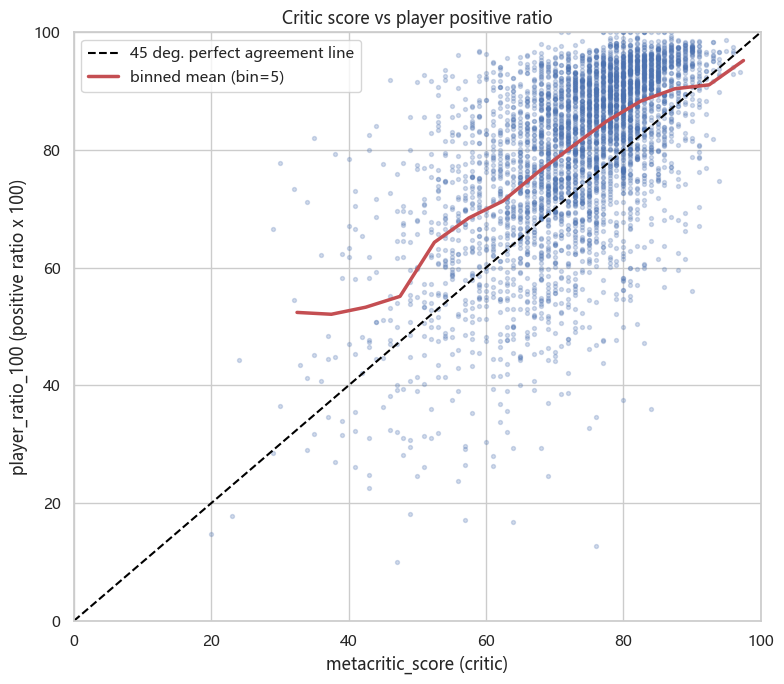

In [21]:
fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(
    core["critic_norm"], core["player_ratio_100"],
    s=8, alpha=0.25, color="#4C72B0",
)
ax.plot([0, 100], [0, 100], color="black", linestyle="--", label="45 deg. perfect agreement line")

bins = np.arange(0, 101, 5)
core["_critic_bin"] = pd.cut(core["critic_norm"], bins=bins, include_lowest=True)
binned = core.groupby("_critic_bin", observed=True)["player_ratio_100"].agg(["mean", "count"]).reset_index()
binned["critic_mid"] = binned["_critic_bin"].apply(lambda x: (x.left + x.right) / 2 if pd.notna(x) else np.nan)
binned = binned[binned["count"] >= 5]

ax.plot(binned["critic_mid"], binned["mean"], color="#C44E52", linewidth=2.5, label="binned mean (bin=5)")

ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.set_xlabel("metacritic_score (critic)")
ax.set_ylabel("player_ratio_100 (positive ratio x 100)")
ax.set_title("Critic score vs player positive ratio")
ax.legend()
plt.tight_layout()
plt.show()

core.drop(columns=["_critic_bin"], inplace=True)

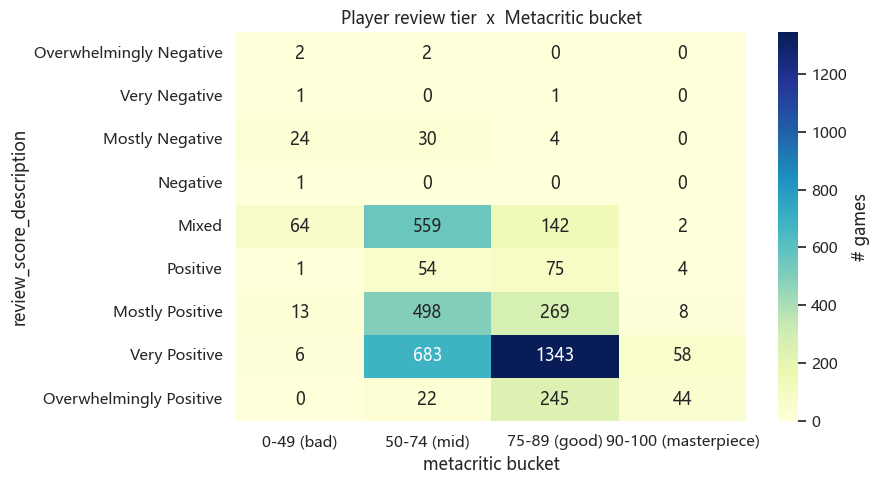

_critic_bucket,0-49 (bad),50-74 (mid),75-89 (good),90-100 (masterpiece)
review_score_description,,,,
Overwhelmingly Negative,2,2,0,0
Very Negative,1,0,1,0
Mostly Negative,24,30,4,0
Negative,1,0,0,0
Mixed,64,559,142,2
Positive,1,54,75,4
Mostly Positive,13,498,269,8
Very Positive,6,683,1343,58
Overwhelmingly Positive,0,22,245,44


In [22]:
metacritic_bins = [0, 49, 74, 89, 100]
metacritic_labels = ["0-49 (bad)", "50-74 (mid)", "75-89 (good)", "90-100 (masterpiece)"]
core["_critic_bucket"] = pd.cut(
    core["critic_norm"], bins=metacritic_bins, labels=metacritic_labels, include_lowest=True,
)

desc_order = [
    "Overwhelmingly Negative", "Very Negative", "Mostly Negative", "Negative",
    "Mixed",
    "Positive", "Mostly Positive", "Very Positive", "Overwhelmingly Positive",
]
desc_present = [d for d in desc_order if d in core["review_score_description"].unique()]

cross = pd.crosstab(
    core["review_score_description"].astype(pd.CategoricalDtype(desc_present, ordered=True)),
    core["_critic_bucket"],
).reindex(index=desc_present)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(cross, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={"label": "# games"}, ax=ax)
ax.set_title("Player review tier  x  Metacritic bucket")
ax.set_xlabel("metacritic bucket")
ax.set_ylabel("review_score_description")
plt.tight_layout()
plt.show()

core.drop(columns=["_critic_bucket"], inplace=True)
cross

## Section 3 — Four-quadrant split

Using the thresholds `player_ratio >= 80%` and `metacritic >= 75`, we assign each title in the core sample to one of four quadrants:

| Quadrant | Players | Critics | Typical interpretation |
| --- | --- | --- | --- |
| Q1  Both Loved       | love | love | Universally acclaimed |
| Q2  Player-Favored   | love | meh  | Hidden gem / under-rated |
| Q3  Critic-Favored   | meh  | love | Inverted reception / over-rated |
| Q4  Both Disliked    | meh  | meh  | Universally panned |

Thresholds are centralised in the `CONFIG` block at the top.

In [23]:
p_thr = CONFIG["player_love_threshold"]
c_thr = CONFIG["critic_love_threshold"]

def assign_quadrant(row):
    p_ok = row["player_ratio"] >= p_thr
    c_ok = row["critic_norm"]  >= c_thr
    if p_ok and c_ok:       return "Q1 Both Loved"
    if p_ok and not c_ok:   return "Q2 Player-Favored"
    if not p_ok and c_ok:   return "Q3 Critic-Favored"
    return "Q4 Both Disliked"

core["quadrant"] = core.apply(assign_quadrant, axis=1)

quad_summary = (
    core["quadrant"]
    .value_counts()
    .reindex(["Q1 Both Loved", "Q2 Player-Favored", "Q3 Critic-Favored", "Q4 Both Disliked"])
    .rename_axis("quadrant")
    .reset_index(name="count")
)
quad_summary["pct"] = (quad_summary["count"] / quad_summary["count"].sum() * 100).round(2).astype(str) + "%"
quad_summary

,quadrant,count,pct
0,Q1 Both Loved,1769,42.58%
1,Q2 Player-Favored,766,18.44%
2,Q3 Critic-Favored,426,10.25%
3,Q4 Both Disliked,1194,28.74%


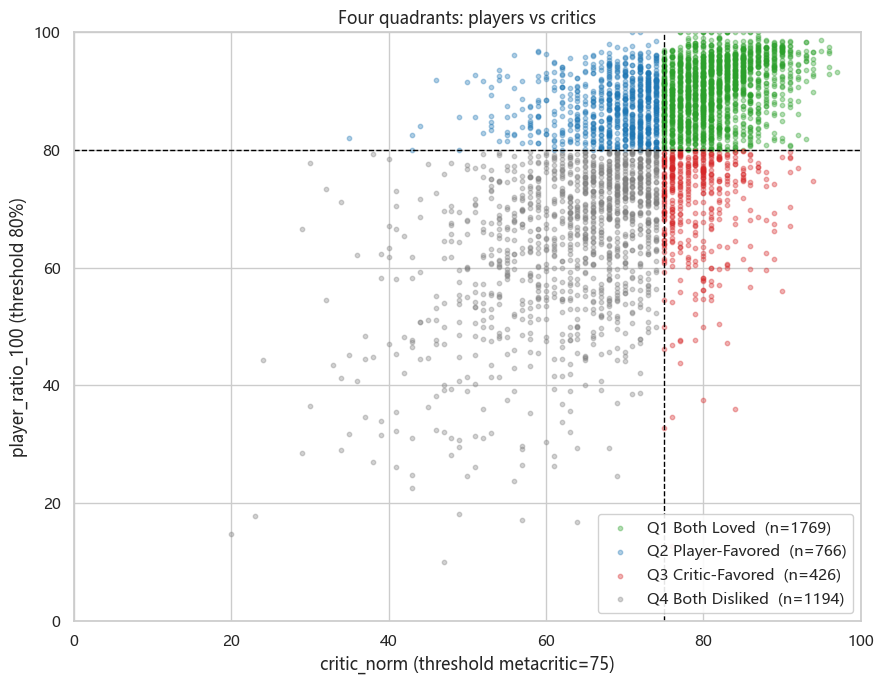

In [24]:
quad_palette = {
    "Q1 Both Loved":       "#2ca02c",
    "Q2 Player-Favored":   "#1f77b4",
    "Q3 Critic-Favored":   "#d62728",
    "Q4 Both Disliked":    "#7f7f7f",
}

fig, ax = plt.subplots(figsize=(9, 7))
for q, color in quad_palette.items():
    sub = core[core["quadrant"] == q]
    ax.scatter(sub["critic_norm"], sub["player_ratio_100"],
               s=10, alpha=0.35, color=color, label=f"{q}  (n={len(sub)})")

ax.axvline(c_thr,       color="black", linestyle="--", linewidth=1)
ax.axhline(p_thr * 100, color="black", linestyle="--", linewidth=1)
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.set_xlabel(f"critic_norm (threshold metacritic={c_thr})")
ax.set_ylabel(f"player_ratio_100 (threshold {int(p_thr*100)}%)")
ax.set_title("Four quadrants: players vs critics")
ax.legend(loc="lower right", framealpha=0.9)
plt.tight_layout()
plt.show()

## Section 4 — Most under-rated / over-rated title lists

Sorting by `divergence_ratio`, we pick the biggest positive-divergence titles (hidden gems) and biggest negative-divergence titles (critic darlings).

To avoid titles making the list purely because of tiny review counts, we additionally require `total >= 200`.

In [25]:
list_cols = [
    "app_id", "name", "developer", "publisher",
    "release_year", "price", "owners_range",
    "total", "player_ratio_100", "critic_norm",
    "divergence_ratio", "quadrant",
]

ranked = core[core["total"] >= 200].copy()

most_underrated = (
    ranked.sort_values("divergence_ratio", ascending=False)
          .head(CONFIG["top_n"])[list_cols]
          .reset_index(drop=True)
)
most_overrated = (
    ranked.sort_values("divergence_ratio", ascending=True)
          .head(CONFIG["top_n"])[list_cols]
          .reset_index(drop=True)
)

def _fmt(df_):
    out = df_.copy()
    out["player_ratio_100"] = out["player_ratio_100"].round(1)
    out["critic_norm"]      = out["critic_norm"].round(0).astype(int)
    out["divergence_ratio"] = out["divergence_ratio"].round(1)
    return out

print(f"[Most under-rated Top {CONFIG['top_n']}] players love it more than critics (positive divergence)")
_fmt(most_underrated)

[Most under-rated Top 15] players love it more than critics (positive divergence)


,app_id,name,developer,publisher,release_year,price,owners_range,total,player_ratio_100,critic_norm,divergence_ratio,quadrant
0,375950,Viridi,"Zoe Vartanian, Badru, Isa Hutchinson, Michael ...",Ice Water Games,2015.0,0.00,"500,000 .. 1,000,000",9145.0,91.8,46,45.8,Q2 Player-Favored
1,388090,Five Nights at Freddy's 4,Scott Cawthon,Scott Cawthon,2015.0,7.99,"500,000 .. 1,000,000",14199.0,92.7,51,41.7,Q2 Player-Favored
2,448370,IS Defense,Destructive Creations,Destructive Creations,2016.0,5.99,"50,000 .. 100,000",1570.0,91.5,50,41.5,Q2 Player-Favored
3,46770,Making History II: The War of the World,Muzzy Lane Software,Factus Games,2010.0,14.99,"50,000 .. 100,000",374.0,79.4,38,41.4,Q4 Both Disliked
4,262190,Zombeer,"Moonbite Games, PadaOne Games",New Gravity Laws,2015.0,4.99,"50,000 .. 100,000",281.0,73.3,32,41.3,Q4 Both Disliked
5,91900,Post Apocalyptic Mayhem,Steel Monkeys,Next Dimension Game Adventures Ltd.,2011.0,9.99,"200,000 .. 500,000",1495.0,84.0,44,40.0,Q2 Player-Favored
6,341940,Hatred,Destructive Creations,Destructive Creations,2015.0,5.99,"500,000 .. 1,000,000",19586.0,82.6,43,39.6,Q2 Player-Favored
7,377080,Hatoful Boyfriend: Holiday Star,Mediatonic,Epic Games,2015.0,9.99,"20,000 .. 50,000",542.0,93.5,54,39.5,Q2 Player-Favored
8,485870,Super Duper Party Pooper,K Bros Games,K Bros Games,2016.0,0.99,"100,000 .. 200,000",445.0,78.4,40,38.4,Q4 Both Disliked
9,401680,POSTAL Redux,Running With Scissors,Running With Scissors,2016.0,8.99,"20,000 .. 50,000",6116.0,91.9,54,37.9,Q2 Player-Favored


In [26]:
print(f"[Most over-rated Top {CONFIG['top_n']}] critics love it more than players (negative divergence)")
_fmt(most_overrated)

[Most over-rated Top 15] critics love it more than players (negative divergence)


,app_id,name,developer,publisher,release_year,price,owners_range,total,player_ratio_100,critic_norm,divergence_ratio,quadrant
0,373960,Audiosurf 2 Demo,Dylan Fitterer,Dylan Fitterer,2015.0,0.00,"0 .. 20,000",259.0,12.7,76,-63.3,Q3 Critic-Favored
1,47700,Command & Conquer™ 4 Tiberian Twilight,EA Los Angeles,Electronic Arts,NaN,19.88,"200,000 .. 500,000",4089.0,16.8,64,-47.2,Q4 Both Disliked
2,283350,Eurofighter Typhoon,Rage Software,Funbox Media Ltd,2014.0,2.99,"20,000 .. 50,000",224.0,24.6,69,-44.4,Q4 Both Disliked
3,13580,Tom Clancy's Splinter Cell Double Agent®,Ubisoft Montreal,Ubisoft,2009.0,2.49,"200,000 .. 500,000",1588.0,37.5,80,-42.5,Q3 Critic-Favored
4,741820,Prey: Typhon Hunter,Arkane Studios,Bethesda Softworks,2018.0,9.99,"50,000 .. 100,000",792.0,32.7,75,-42.3,Q3 Critic-Favored
5,201490,Airline Tycoon 2,b-Alive,Kalypso Media Digital,2011.0,9.99,"50,000 .. 100,000",561.0,17.1,57,-39.9,Q4 Both Disliked
6,289820,Dracula 2: The Last Sanctuary,Microids,Microids,2014.0,4.99,"20,000 .. 50,000",258.0,29.5,68,-38.5,Q4 Both Disliked
7,214150,Galactic Civilizations® I: Ultimate Edition,Stardock Entertainment,Stardock Entertainment,2012.0,9.99,"200,000 .. 500,000",271.0,47.2,83,-35.8,Q3 Critic-Favored
8,34920,Razor2: Hidden Skies,Invent4 Entertainment,Strategy First,2010.0,7.99,"50,000 .. 100,000",228.0,26.3,61,-34.7,Q4 Both Disliked
9,8880,Freedom Force,Irrational Games,2K,2009.0,4.99,"100,000 .. 200,000",509.0,56.0,90,-34.0,Q3 Critic-Favored


## Section 5 — Slice by genre

A game can carry multiple genres, so one title contributes to every genre it belongs to (standard practice for Steam data).
We only keep genres with at least `min_games_per_genre` games in the core sample.

In [27]:
def slice_by_long_table(long_df, key_col, min_games):
    """Join core with a long table on app_id, then aggregate divergence by key_col."""
    joined = long_df.merge(
        core[["app_id", "divergence_ratio", "quadrant"]],
        on="app_id", how="inner",
    )
    agg = (
        joined.groupby(key_col)
              .agg(n_games=("app_id", "nunique"),
                   mean_div=("divergence_ratio", "mean"),
                   median_div=("divergence_ratio", "median"))
              .reset_index()
    )
    quad_pct = (
        joined.groupby([key_col, "quadrant"])["app_id"].nunique()
              .unstack("quadrant").fillna(0)
    )
    quad_pct = quad_pct.div(quad_pct.sum(axis=1), axis=0) * 100
    quad_pct = quad_pct.add_prefix("pct_").reset_index()

    out = agg.merge(quad_pct, on=key_col)
    out = out[out["n_games"] >= min_games].copy()
    out["mean_div"]   = out["mean_div"].round(2)
    out["median_div"] = out["median_div"].round(2)
    for c in [c for c in out.columns if c.startswith("pct_")]:
        out[c] = out[c].round(1)
    return out.sort_values("mean_div", ascending=False).reset_index(drop=True)

genre_stats = slice_by_long_table(genres_long, "genre", CONFIG["min_games_per_genre"])
print(f"Genre slice (n_games >= {CONFIG['min_games_per_genre']}): {len(genre_stats)} genres kept")
genre_stats

Genre slice (n_games >= 20): 11 genres kept


,genre,n_games,mean_div,median_div,pct_Q1 Both Loved,pct_Q2 Player-Favored,pct_Q3 Critic-Favored,pct_Q4 Both Disliked
0,Casual,544,9.32,10.86,43.4,25.9,8.1,22.6
1,Indie,2299,8.60,9.57,42.0,21.2,8.4,28.4
2,Adventure,1872,8.33,9.28,43.3,19.9,9.5,27.3
3,Action,2051,7.34,8.28,42.5,18.9,10.2,28.4
4,Racing,136,6.98,7.61,33.1,25.0,14.7,27.2
5,Simulation,617,6.48,7.50,34.5,21.9,9.2,34.4
6,RPG,898,5.92,7.28,44.9,15.1,10.4,29.6
7,Sports,127,5.02,6.06,37.0,17.3,14.2,31.5
8,Strategy,1023,3.99,5.88,39.4,14.0,13.3,33.3
9,Free To Play,88,1.75,1.00,28.4,13.6,28.4,29.5


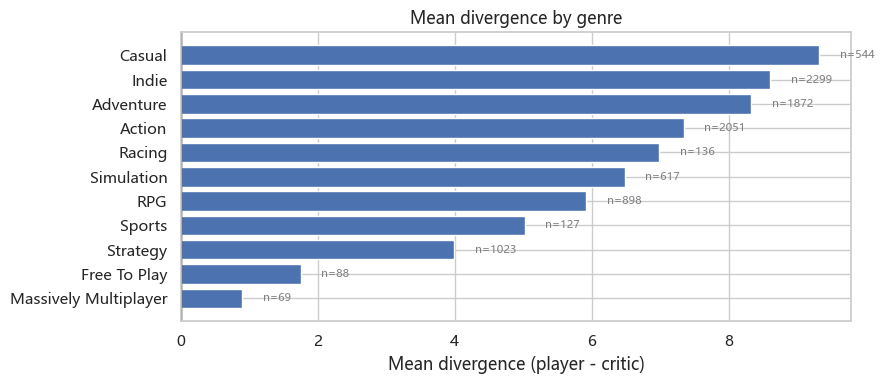

In [28]:
fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(genre_stats))))
genre_plot = genre_stats.sort_values("mean_div")
colors = ["#4C72B0" if v >= 0 else "#C44E52" for v in genre_plot["mean_div"]]
ax.barh(genre_plot["genre"], genre_plot["mean_div"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Mean divergence (player - critic)")
ax.set_title("Mean divergence by genre")
for y, (v, n) in enumerate(zip(genre_plot["mean_div"], genre_plot["n_games"])):
    ax.text(v + (0.3 if v >= 0 else -0.3), y, f"n={n}",
            va="center", ha="left" if v >= 0 else "right", fontsize=8, color="gray")
plt.tight_layout()
plt.show()

## Section 6 — Slice by category & tag

- `category` has a small cardinality, so we reuse the same mean-divergence bar chart as genre
- `tag` has a huge cardinality (thousands), so instead we compare: **tags with the biggest frequency gap between "Player-Favored (Q2)" and "Critic-Favored (Q3)"**, using a *mirrored bar chart* to surface each side's signature tags

Category slice (n_games >= 20): 37 categories kept


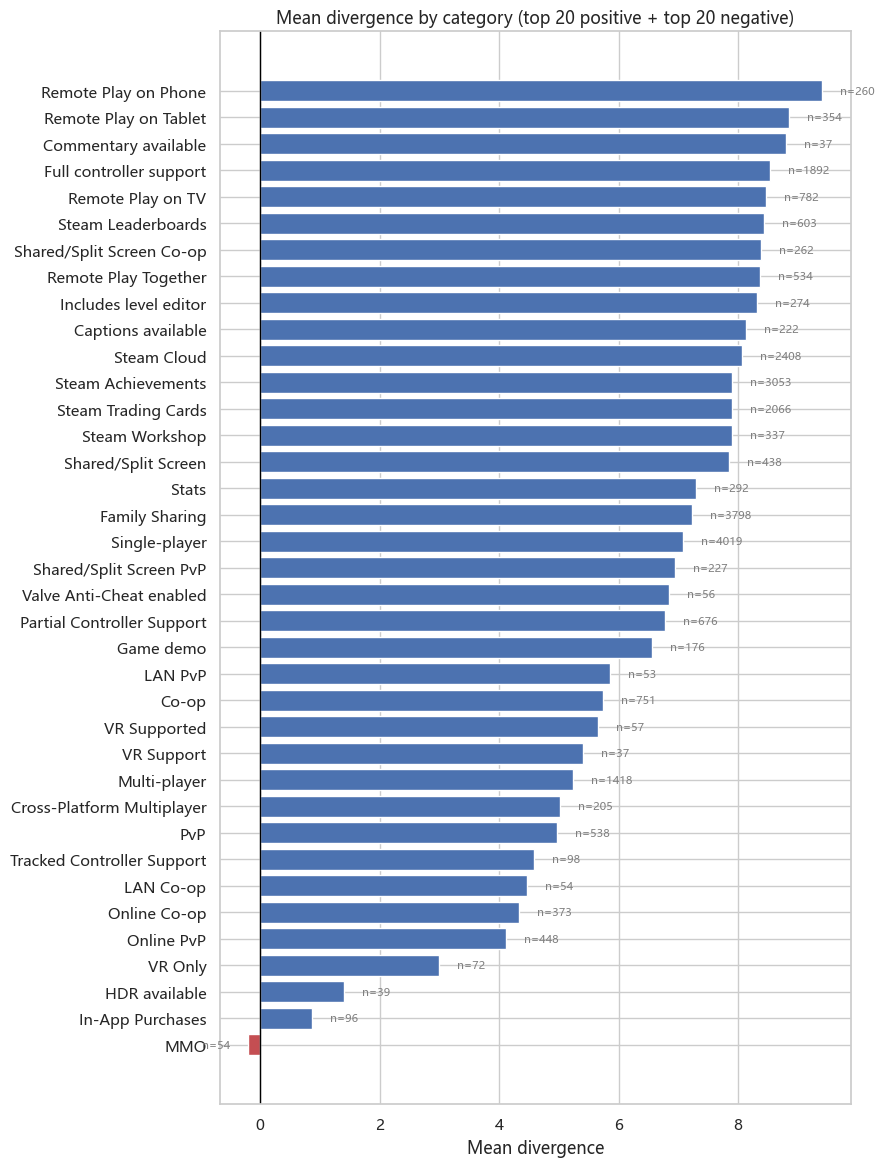

,category,n_games,mean_div,median_div,pct_Q1 Both Loved,pct_Q2 Player-Favored,pct_Q3 Critic-Favored,pct_Q4 Both Disliked
0,Remote Play on Phone,260,9.41,9.71,80.0,11.5,5.0,3.5
1,Remote Play on Tablet,354,8.85,9.31,78.0,12.1,5.1,4.8
2,Commentary available,37,8.80,9.14,67.6,18.9,8.1,5.4
3,Full controller support,1892,8.54,9.33,49.8,18.3,8.0,23.8
4,Remote Play on TV,782,8.47,9.48,49.6,17.4,7.4,25.6
5,Steam Leaderboards,603,8.44,9.25,42.1,23.5,8.6,25.7
6,Shared/Split Screen Co-op,262,8.38,9.67,51.1,19.1,6.9,22.9
7,Remote Play Together,534,8.37,9.53,49.3,20.8,8.1,21.9
8,Includes level editor,274,8.32,8.89,51.8,19.7,8.8,19.7
9,Captions available,222,8.13,9.03,43.2,20.7,6.8,29.3


In [29]:
category_stats = slice_by_long_table(categories_long, "category", CONFIG["min_games_per_category"])
print(f"Category slice (n_games >= {CONFIG['min_games_per_category']}): {len(category_stats)} categories kept")

top_n_cat = 20
cat_plot = pd.concat([category_stats.head(top_n_cat), category_stats.tail(top_n_cat)]).drop_duplicates()
cat_plot = cat_plot.sort_values("mean_div")

fig, ax = plt.subplots(figsize=(9, max(4, 0.32 * len(cat_plot))))
colors = ["#4C72B0" if v >= 0 else "#C44E52" for v in cat_plot["mean_div"]]
ax.barh(cat_plot["category"], cat_plot["mean_div"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Mean divergence")
ax.set_title(f"Mean divergence by category (top {top_n_cat} positive + top {top_n_cat} negative)")
for y, (v, n) in enumerate(zip(cat_plot["mean_div"], cat_plot["n_games"])):
    ax.text(v + (0.3 if v >= 0 else -0.3), y, f"n={n}",
            va="center", ha="left" if v >= 0 else "right", fontsize=8, color="gray")
plt.tight_layout()
plt.show()

category_stats.head(10)

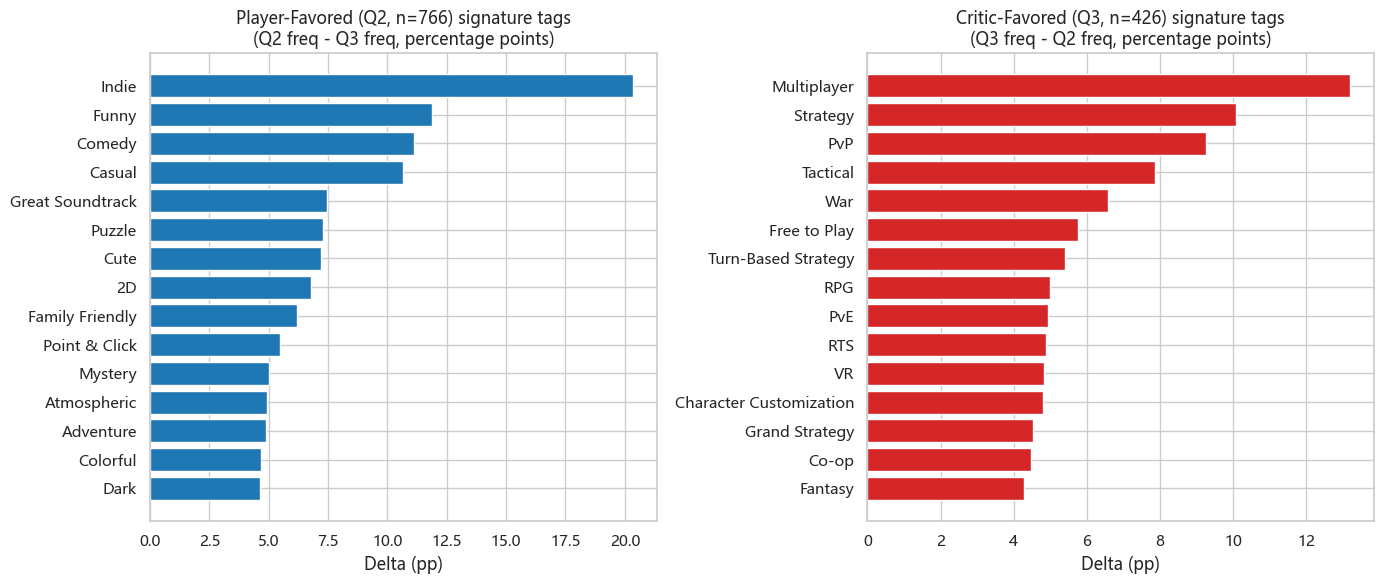

In [30]:
tag_joined = tags_long.merge(core[["app_id", "quadrant"]], on="app_id", how="inner")
q2_ids = set(core.loc[core["quadrant"] == "Q2 Player-Favored", "app_id"])
q3_ids = set(core.loc[core["quadrant"] == "Q3 Critic-Favored", "app_id"])

def tag_freq(tag_df, app_ids):
    sub = tag_df[tag_df["app_id"].isin(app_ids)]
    counts = sub["tag"].value_counts()
    return (counts / len(app_ids) * 100).rename("pct")

q2_freq = tag_freq(tags_long, q2_ids)
q3_freq = tag_freq(tags_long, q3_ids)

tag_compare = pd.concat([q2_freq, q3_freq], axis=1, keys=["q2_pct", "q3_pct"]).fillna(0)
tag_compare["support"] = (tag_compare["q2_pct"] / 100 * len(q2_ids)) + (tag_compare["q3_pct"] / 100 * len(q3_ids))
tag_compare = tag_compare[tag_compare["support"] >= 10]
tag_compare["diff"] = tag_compare["q2_pct"] - tag_compare["q3_pct"]

n_each = 15
top_q2 = tag_compare.nlargest(n_each, "diff")
top_q3 = tag_compare.nsmallest(n_each, "diff")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

axes[0].barh(top_q2.index[::-1], top_q2["diff"][::-1], color="#1f77b4")
axes[0].set_title(f"Player-Favored (Q2, n={len(q2_ids)}) signature tags\n(Q2 freq - Q3 freq, percentage points)")
axes[0].set_xlabel("Delta (pp)")

axes[1].barh(top_q3.index[::-1], -top_q3["diff"][::-1], color="#d62728")
axes[1].set_title(f"Critic-Favored (Q3, n={len(q3_ids)}) signature tags\n(Q3 freq - Q2 freq, percentage points)")
axes[1].set_xlabel("Delta (pp)")

plt.tight_layout()
plt.show()

## Section 7 — Slice by publisher / developer

Which studios are systematically boosted by players (positive divergence: word-of-mouth outpaces critics), and which are systematically boosted by critics (negative divergence)?
Minimum games per entity is controlled by `min_games_per_publisher` / `min_games_per_developer`.

In [31]:
def entity_stats(col, min_games):
    sub = core[core[col].notna()]
    agg = (sub.groupby(col)
              .agg(n_games=("app_id", "nunique"),
                   mean_div=("divergence_ratio", "mean"),
                   median_div=("divergence_ratio", "median"),
                   mean_player=("player_ratio_100", "mean"),
                   mean_critic=("critic_norm", "mean"))
              .reset_index())
    agg = agg[agg["n_games"] >= min_games].copy()
    for c in ["mean_div", "median_div", "mean_player", "mean_critic"]:
        agg[c] = agg[c].round(1)
    return agg

pub_stats = entity_stats("publisher", CONFIG["min_games_per_publisher"])
dev_stats = entity_stats("developer", CONFIG["min_games_per_developer"])

print(f"Publisher candidates (n_games >= {CONFIG['min_games_per_publisher']}): {len(pub_stats)}")
print(f"Developer candidates (n_games >= {CONFIG['min_games_per_developer']}): {len(dev_stats)}")

print("\n[Publisher - most under-rated Top 15 (highest mean_div)]")
pub_top = pub_stats.nlargest(CONFIG["top_n"], "mean_div").reset_index(drop=True)
pub_top

Publisher candidates (n_games >= 5): 145
Developer candidates (n_games >= 5): 105

[Publisher - most under-rated Top 15 (highest mean_div)]


,publisher,n_games,mean_div,median_div,mean_player,mean_critic
0,Scott Cawthon,5,27.9,28.7,92.1,64.2
1,SCS Software,5,19.2,18.6,93.4,74.2
2,"XSEED Games, Marvelous USA, Inc., Marvelous",9,18.0,18.5,85.4,67.3
3,"NIS America, Inc.",6,15.9,15.6,82.9,67.0
4,Coffee Stain Publishing,7,15.5,13.0,92.9,77.4
5,Rebellion,24,15.0,16.0,82.7,67.7
6,Telltale Games,5,14.6,14.3,86.2,71.6
7,"XSEED Games, Marvelous USA, Inc.",15,14.5,14.1,91.1,76.6
8,Nightdive Studios,8,14.0,11.8,87.6,73.6
9,PLAYISM,14,13.7,13.1,84.5,70.8


In [32]:
print("[Publisher - most over-rated Top 15 (lowest mean_div)]")
pub_bot = pub_stats.nsmallest(CONFIG["top_n"], "mean_div").reset_index(drop=True)
pub_bot

[Publisher - most over-rated Top 15 (lowest mean_div)]


,publisher,n_games,mean_div,median_div,mean_player,mean_critic
0,Stardock Entertainment,12,-8.2,-5.9,72.0,80.2
1,Funbox Media Ltd,7,-6.9,-9.8,61.1,68.0
2,"Arcen Games, LLC",9,-5.7,2.7,63.1,68.8
3,Kalypso Media Digital,27,-5.2,-3.8,64.3,69.4
4,Tribute Games Inc.,5,-4.5,-5.5,72.5,77.0
5,"SEGA, Feral Interactive (Mac), Feral Interacti...",12,-3.7,-0.2,79.8,83.5
6,Microids,18,-3.6,-0.6,67.4,71.0
7,Viva Media,8,-3.4,-3.4,59.3,62.8
8,Eidos Interactive Corp.,7,-2.9,0.4,78.5,81.4
9,Nival,5,-2.7,6.0,68.5,71.2


[Developer - most under-rated Top 15]
[Developer - most over-rated Top 15]


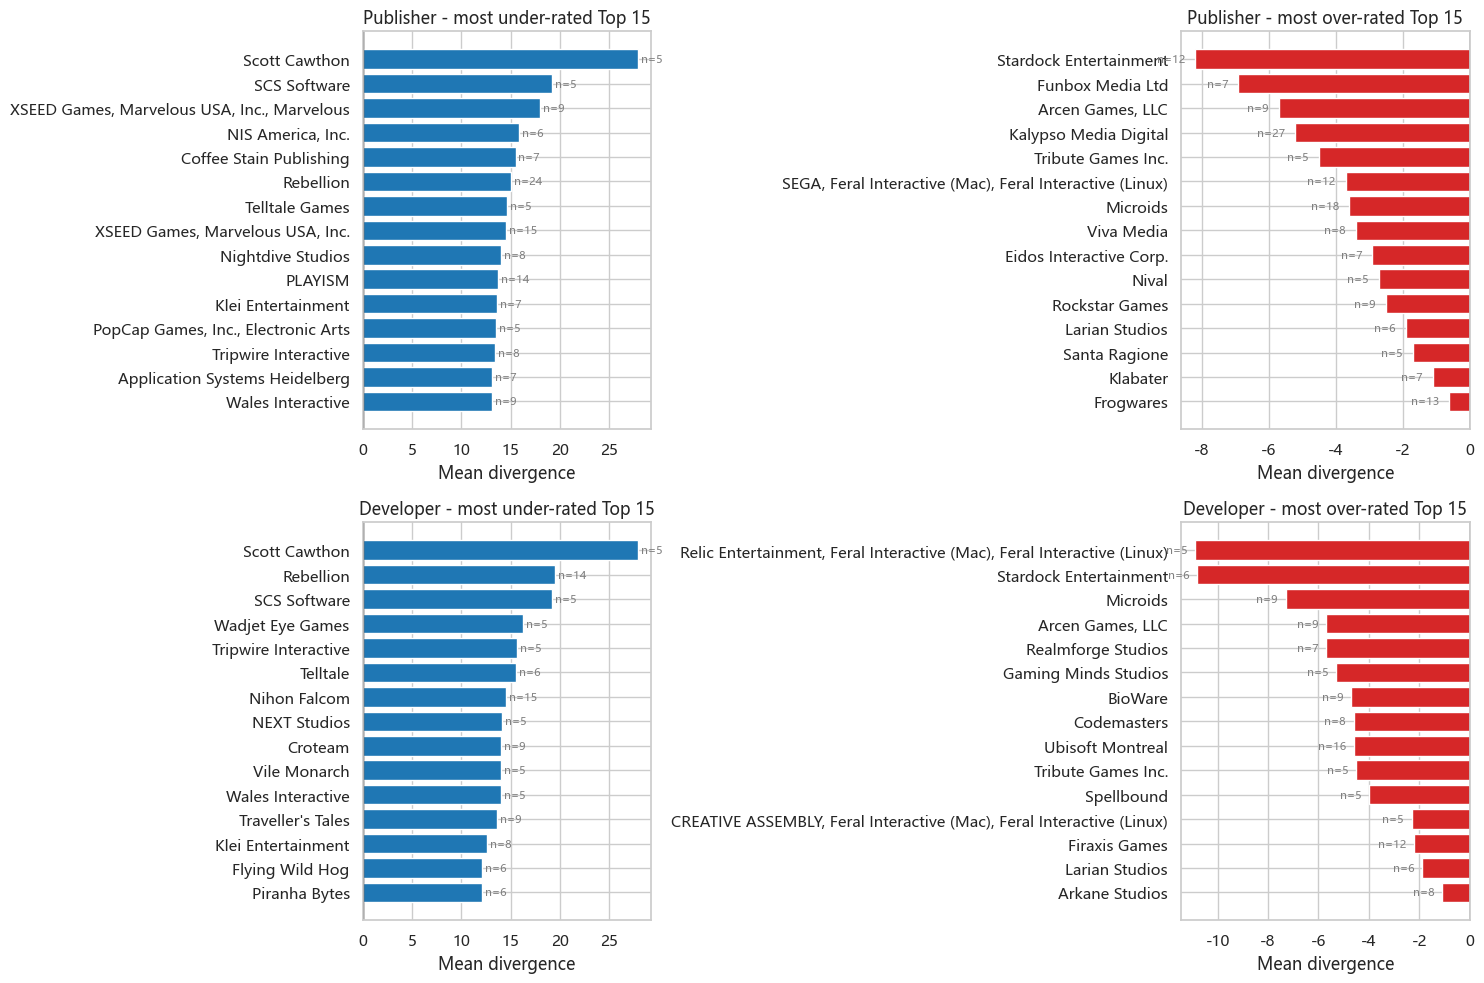

,developer,n_games,mean_div,median_div,mean_player,mean_critic
0,Scott Cawthon,5,27.9,28.7,92.1,64.2
1,Rebellion,14,19.5,19.3,85.4,65.9
2,SCS Software,5,19.2,18.6,93.4,74.2
3,Wadjet Eye Games,5,16.3,15.3,93.5,77.2
4,Tripwire Interactive,5,15.7,16.6,90.5,74.8
5,Telltale,6,15.6,14.1,90.8,75.2
6,Nihon Falcom,15,14.5,14.2,91.7,77.2
7,NEXT Studios,5,14.1,12.6,88.7,74.6
8,Croteam,9,14.0,15.1,92.1,78.1
9,Vile Monarch,5,14.0,18.9,80.2,66.2


In [33]:
print("[Developer - most under-rated Top 15]")
dev_top = dev_stats.nlargest(CONFIG["top_n"], "mean_div").reset_index(drop=True)
print("[Developer - most over-rated Top 15]")
dev_bot = dev_stats.nsmallest(CONFIG["top_n"], "mean_div").reset_index(drop=True)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, df_, title, color in [
    (axes[0, 0], pub_top.iloc[::-1], "Publisher - most under-rated Top 15", "#1f77b4"),
    (axes[0, 1], pub_bot.iloc[::-1], "Publisher - most over-rated Top 15", "#d62728"),
    (axes[1, 0], dev_top.iloc[::-1], "Developer - most under-rated Top 15", "#1f77b4"),
    (axes[1, 1], dev_bot.iloc[::-1], "Developer - most over-rated Top 15", "#d62728"),
]:
    key_col = df_.columns[0]
    ax.barh(df_[key_col], df_["mean_div"], color=color)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Mean divergence")
    for y, (v, n) in enumerate(zip(df_["mean_div"], df_["n_games"])):
        ax.text(v + (0.3 if v >= 0 else -0.3), y, f"n={n}",
                va="center", ha="left" if v >= 0 else "right", fontsize=8, color="gray")

plt.tight_layout()
plt.show()

dev_top

In [34]:
dev_bot

,developer,n_games,mean_div,median_div,mean_player,mean_critic
0,"Relic Entertainment, Feral Interactive (Mac), ...",5,-10.9,-6.1,68.7,79.6
1,Stardock Entertainment,6,-10.8,-10.2,67.5,78.3
2,Microids,9,-7.3,-3.0,64.3,71.6
3,"Arcen Games, LLC",9,-5.7,2.7,63.1,68.8
4,Realmforge Studios,7,-5.7,-11.6,62.4,68.1
5,Gaming Minds Studios,5,-5.3,-5.3,63.5,68.8
6,BioWare,9,-4.7,-3.7,80.7,85.4
7,Codemasters,8,-4.6,-6.4,72.3,76.9
8,Ubisoft Montreal,16,-4.6,-4.3,78.0,82.6
9,Tribute Games Inc.,5,-4.5,-5.5,72.5,77.0


## Section 8 — Slice by price / free vs paid / owners range

Do player-critic divergence patterns differ along commercial dimensions? Three slices:

- `price` buckets: 0 / 0-5 / 5-15 / 15-30 / 30-60 / 60+ USD
- `is_free`: free vs paid
- `owners_range`: ordered owners buckets

In [35]:
price_bins   = [-0.01, 0.001, 5, 15, 30, 60, np.inf]
price_labels = ["0 (free)", "(0, 5]", "(5, 15]", "(15, 30]", "(30, 60]", "60+"]
core["price_bucket"] = pd.cut(core["price"], bins=price_bins, labels=price_labels)

price_summary = (
    core.dropna(subset=["price_bucket"])
        .groupby("price_bucket", observed=True)["divergence_ratio"]
        .agg(["count", "mean", "median"]).round(2)
        .rename(columns={"count": "n_games", "mean": "mean_div", "median": "median_div"})
        .reset_index()
)
price_summary

,price_bucket,n_games,mean_div,median_div
0,0 (free),362,4.51,6.18
1,"(0, 5]",601,6.49,7.68
2,"(5, 15]",1601,8.03,9.34
3,"(15, 30]",1292,7.27,8.56
4,"(30, 60]",275,3.57,4.87
5,60+,11,0.46,1.94


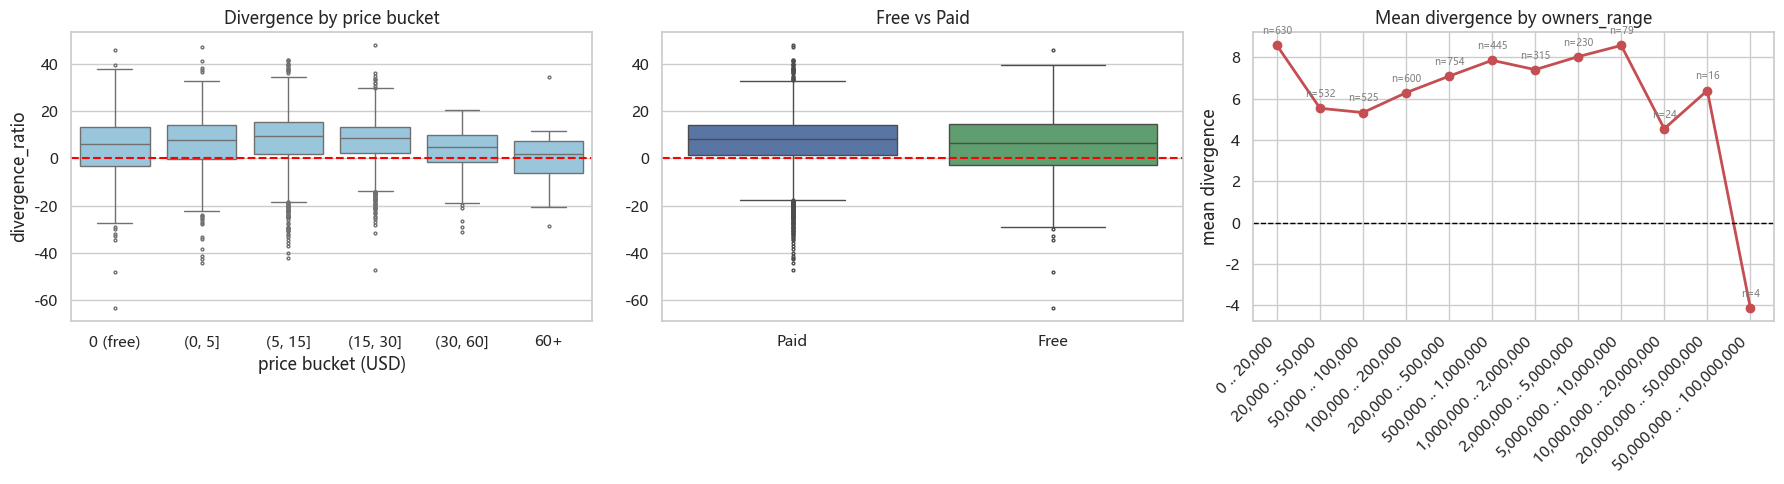


Free vs Paid divergence (mean & median):
      count  mean  median
type                     
Free    285  5.33    6.33
Paid   3870  7.05    8.29


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_df = core.dropna(subset=["price_bucket"])
sns.boxplot(data=plot_df, x="price_bucket", y="divergence_ratio",
            ax=axes[0], color="#8ecae6", fliersize=2)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Divergence by price bucket")
axes[0].set_xlabel("price bucket (USD)")
axes[0].set_ylabel("divergence_ratio")

free_df = core.dropna(subset=["is_free"]).copy()
free_df["type"] = free_df["is_free"].map({0: "Paid", 1: "Free"})
sns.boxplot(data=free_df, x="type", y="divergence_ratio",
            ax=axes[1], palette={"Paid": "#4C72B0", "Free": "#55A868"}, fliersize=2)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Free vs Paid")
axes[1].set_xlabel(""); axes[1].set_ylabel("")

owners_summary = (
    core.dropna(subset=["owners_range"])
        .groupby("owners_range", observed=True)["divergence_ratio"]
        .agg(["count", "mean"]).reset_index()
        .rename(columns={"count": "n_games", "mean": "mean_div"})
)
owners_summary = owners_summary.sort_values("owners_range")

axes[2].plot(range(len(owners_summary)), owners_summary["mean_div"],
             marker="o", color="#C44E52", linewidth=2)
axes[2].axhline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_xticks(range(len(owners_summary)))
axes[2].set_xticklabels(owners_summary["owners_range"].astype(str), rotation=45, ha="right")
axes[2].set_title("Mean divergence by owners_range")
axes[2].set_ylabel("mean divergence")

for i, n in enumerate(owners_summary["n_games"]):
    axes[2].annotate(f"n={n}",
                     xy=(i, owners_summary["mean_div"].iloc[i]),
                     xytext=(0, 8), textcoords="offset points",
                     ha="center", fontsize=7, color="gray")

plt.tight_layout()
plt.show()

print("\nFree vs Paid divergence (mean & median):")
print(free_df.groupby("type")["divergence_ratio"].agg(["count", "mean", "median"]).round(2))

## Section 9 — Trend by release year

Does the player-critic divergence shift over time? We overlay sample-size bars so years with fewer than ~10 samples can be read with appropriate caution.

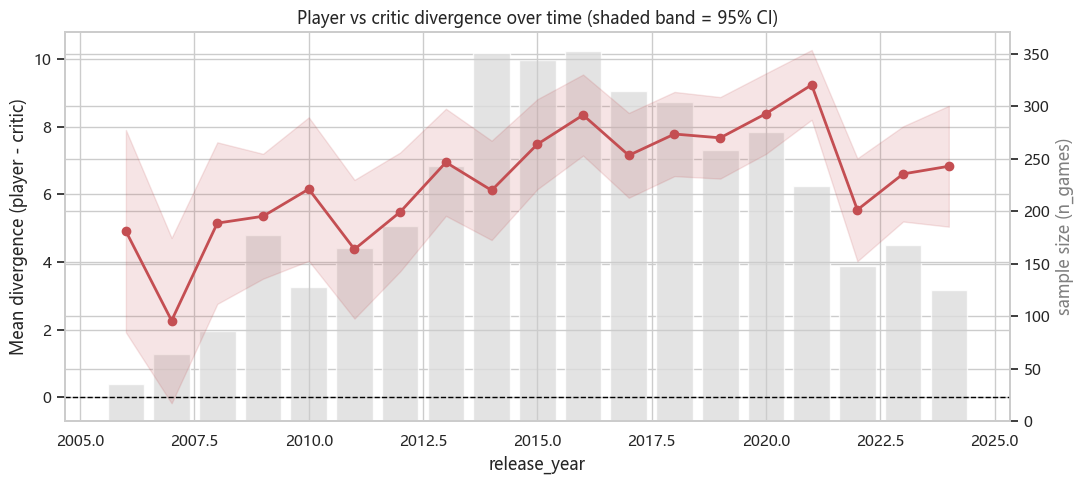

,release_year,n_games,mean_div,sem,ci95
7,2006,35.0,4.91,1.53,2.99
8,2007,64.0,2.27,1.25,2.44
9,2008,86.0,5.15,1.22,2.39
10,2009,177.0,5.35,0.94,1.84
11,2010,128.0,6.16,1.08,2.12
12,2011,165.0,4.38,1.05,2.05
13,2012,186.0,5.48,0.90,1.76
14,2013,243.0,6.95,0.81,1.58
15,2014,351.0,6.12,0.75,1.47
16,2015,344.0,7.48,0.68,1.33


In [37]:
year_df = core.dropna(subset=["release_year"]).copy()
year_df["release_year"] = year_df["release_year"].astype(int)

def agg_year(g):
    n = len(g)
    mean = g["divergence_ratio"].mean()
    sem  = g["divergence_ratio"].std(ddof=1) / np.sqrt(n) if n > 1 else np.nan
    return pd.Series({"n_games": n, "mean_div": mean, "sem": sem})

year_stats = (year_df.groupby("release_year").apply(agg_year).reset_index())
year_stats = year_stats[year_stats["n_games"] >= 5]
year_stats["ci95"] = 1.96 * year_stats["sem"]

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax2.bar(year_stats["release_year"], year_stats["n_games"],
        color="#dddddd", alpha=0.8, label="sample size")
ax2.set_ylabel("sample size (n_games)", color="gray")

ax1.fill_between(
    year_stats["release_year"],
    year_stats["mean_div"] - year_stats["ci95"],
    year_stats["mean_div"] + year_stats["ci95"],
    color="#C44E52", alpha=0.15,
)
ax1.plot(year_stats["release_year"], year_stats["mean_div"],
         color="#C44E52", linewidth=2, marker="o", label="mean divergence")
ax1.axhline(0, color="black", linestyle="--", linewidth=1)
ax1.set_ylabel("Mean divergence (player - critic)")
ax1.set_xlabel("release_year")
ax1.set_title("Player vs critic divergence over time (shaded band = 95% CI)")

ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

plt.tight_layout()
plt.show()

year_stats.round(2)

## Section 10 — Divergence vs review volume

Do more controversial titles attract more reviews? We inspect the relationship between `|divergence_ratio|` and `log10(total)`.

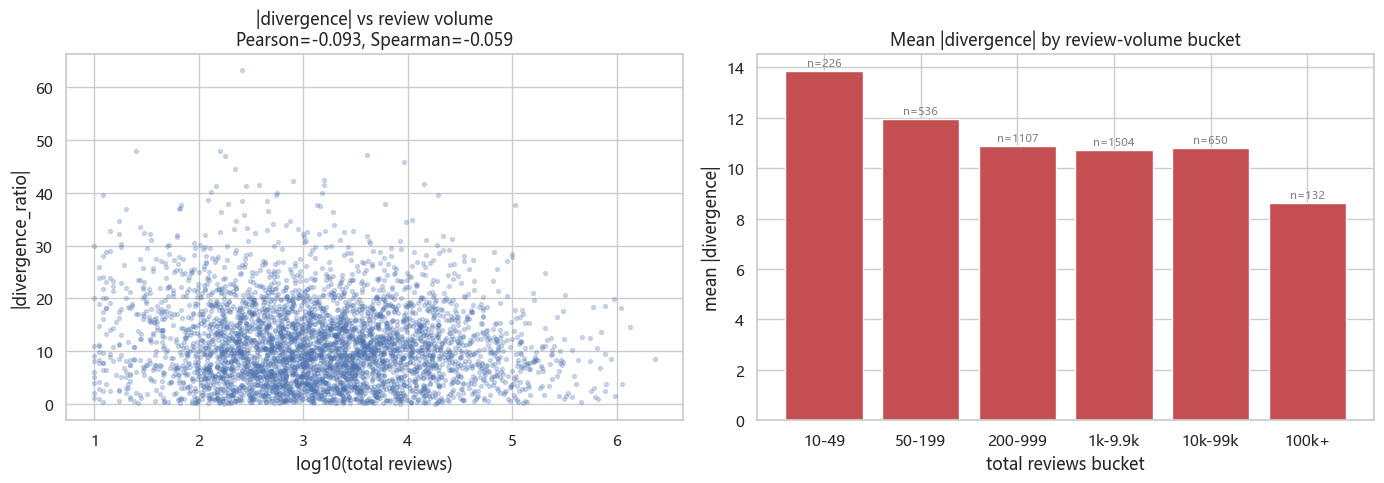

,total_bucket,n_games,mean_abs_div,median_abs_div
0,10-49,226,13.85,13.00
1,50-199,536,11.94,10.18
2,200-999,1107,10.89,9.73
3,1k-9.9k,1504,10.73,9.81
4,10k-99k,650,10.78,9.95
5,100k+,132,8.63,7.99


In [38]:
core["abs_div"]    = core["divergence_ratio"].abs()
core["log_total"]  = np.log10(core["total"])

spearman_r = core[["abs_div", "log_total"]].corr(method="spearman").iloc[0, 1]
pearson_r  = core[["abs_div", "log_total"]].corr().iloc[0, 1]

total_bins = [10, 50, 200, 1000, 10_000, 100_000, np.inf]
total_labels = ["10-49", "50-199", "200-999", "1k-9.9k", "10k-99k", "100k+"]
core["total_bucket"] = pd.cut(core["total"], bins=total_bins, labels=total_labels,
                              include_lowest=True, right=False)

bucket_summary = (
    core.groupby("total_bucket", observed=True)["abs_div"]
        .agg(["count", "mean", "median"]).round(2)
        .rename(columns={"count": "n_games", "mean": "mean_abs_div", "median": "median_abs_div"})
        .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(core["log_total"], core["abs_div"], alpha=0.25, s=8, color="#4C72B0")
axes[0].set_xlabel("log10(total reviews)")
axes[0].set_ylabel("|divergence_ratio|")
axes[0].set_title(f"|divergence| vs review volume\nPearson={pearson_r:.3f}, Spearman={spearman_r:.3f}")

axes[1].bar(bucket_summary["total_bucket"].astype(str),
            bucket_summary["mean_abs_div"], color="#C44E52")
axes[1].set_title("Mean |divergence| by review-volume bucket")
axes[1].set_xlabel("total reviews bucket")
axes[1].set_ylabel("mean |divergence|")
for i, (v, n) in enumerate(zip(bucket_summary["mean_abs_div"], bucket_summary["n_games"])):
    axes[1].text(i, v + 0.2, f"n={n}", ha="center", fontsize=8, color="gray")

plt.tight_layout()
plt.show()

bucket_summary

## Section 11 — Summary

The next cell automatically generates a summary printout of the key numbers from this analysis (correlations, quadrant shares, most positive/negative divergence genres/publishers/price buckets/years, |divergence| vs review-volume correlation, etc.) so it can be read aloud directly as a briefing.

In [39]:
lines = []
lines.append("=" * 64)
lines.append("  Player vs Critic Divergence  -  Auto Summary")
lines.append("=" * 64)

lines.append(f"\n[Sample] Raw reviews {n_raw:,} rows; with metacritic {n_has_metacritic:,}; "
             f"core sample (also total >= {CONFIG['min_total_reviews']}) {len(core):,} rows.")

lines.append(f"\n[Correlation] Within the core sample:")
lines.append(f"  Pearson (player_ratio_100 vs critic)   = {corrs['pearson'][0]:.3f}")
lines.append(f"  Spearman(player_ratio_100 vs critic)   = {corrs['spearman'][0]:.3f}")

lines.append(f"\n[Four quadrants]  thresholds: player>={int(p_thr*100)}%, critic>={c_thr}")
for _, r in quad_summary.iterrows():
    lines.append(f"  {r['quadrant']:<22s} {int(r['count']):>5d}  ({r['pct']})")

lines.append(f"\n[Top 3 most under-rated titles] (largest divergence, total>=200)")
for _, r in most_underrated.head(3).iterrows():
    lines.append(f"  {r['name'][:40]:<40s}  player={r['player_ratio_100']:.1f}, critic={int(r['critic_norm'])}, d={r['divergence_ratio']:+.1f}")

lines.append(f"\n[Top 3 most over-rated titles] (smallest divergence)")
for _, r in most_overrated.head(3).iterrows():
    lines.append(f"  {r['name'][:40]:<40s}  player={r['player_ratio_100']:.1f}, critic={int(r['critic_norm'])}, d={r['divergence_ratio']:+.1f}")

g_top = genre_stats.sort_values("mean_div", ascending=False).head(3)
g_bot = genre_stats.sort_values("mean_div", ascending=True ).head(3)
lines.append("\n[Genres with highest divergence (players prefer) Top 3]")
for _, r in g_top.iterrows():
    lines.append(f"  {r['genre']:<25s} mean={r['mean_div']:+.2f}  (n={r['n_games']})")
lines.append("[Genres with lowest divergence (critics prefer) Bottom 3]")
for _, r in g_bot.iterrows():
    lines.append(f"  {r['genre']:<25s} mean={r['mean_div']:+.2f}  (n={r['n_games']})")

lines.append("\n[Publishers systematically under-rated Top 3]")
for _, r in pub_top.head(3).iterrows():
    lines.append(f"  {r['publisher']:<40s} mean={r['mean_div']:+.2f}  (n={r['n_games']})")
lines.append("[Publishers systematically over-rated Top 3]")
for _, r in pub_bot.head(3).iterrows():
    lines.append(f"  {r['publisher']:<40s} mean={r['mean_div']:+.2f}  (n={r['n_games']})")

lines.append("\n[Mean divergence by price bucket]")
for _, r in price_summary.iterrows():
    lines.append(f"  {str(r['price_bucket']):<10s} mean_div={r['mean_div']:+.2f}  median={r['median_div']:+.2f}  (n={int(r['n_games'])})")

lines.append("\n[Free vs Paid mean divergence]")
_free_means = free_df.groupby("type")["divergence_ratio"].mean().round(2)
for k, v in _free_means.items():
    lines.append(f"  {k}: {v:+.2f}")

peak_pos = year_stats.loc[year_stats["mean_div"].idxmax()]
peak_neg = year_stats.loc[year_stats["mean_div"].idxmin()]
lines.append(f"\n[Year trend] Most positive year: {int(peak_pos['release_year'])} (mean={peak_pos['mean_div']:+.2f}, n={int(peak_pos['n_games'])})")
lines.append(f"             Most negative year: {int(peak_neg['release_year'])} (mean={peak_neg['mean_div']:+.2f}, n={int(peak_neg['n_games'])})")

lines.append(f"\n[|divergence| vs review volume] Pearson={pearson_r:+.3f}  Spearman={spearman_r:+.3f}")

lines.append("\n" + "=" * 64)
lines.append("Bottom line")
lines.append("=" * 64)
overall_corr = corrs["spearman"][0]
consensus_pct = float(quad_summary.loc[quad_summary["quadrant"].isin(
    ["Q1 Both Loved", "Q4 Both Disliked"]), "count"].sum()) / quad_summary["count"].sum() * 100
lines.append(f"- Overall player-critic Spearman correlation is about {overall_corr:.2f}; "
             f"roughly {consensus_pct:.0f}% of titles agree (Q1+Q4).")
lines.append("- Real systematic divergence is concentrated in a handful of genres, studios, "
             "price tiers and years - these slices are the source of 'hidden gem' and "
             "'critic darling' reputations.")
lines.append("- Controversy correlates weakly with review volume, so exposure/sales are not "
             "the main drivers of divergence.")

print("\n".join(lines))

  Player vs Critic Divergence  -  Auto Summary

[Sample] Raw reviews 140,082 rows; with metacritic 4,745; core sample (also total >= 10) 4,155 rows.

[Correlation] Within the core sample:
  Pearson (player_ratio_100 vs critic)   = 0.597
  Spearman(player_ratio_100 vs critic)   = 0.576

[Four quadrants]  thresholds: player>=80%, critic>=75
  Q1 Both Loved           1769  (42.58%)
  Q2 Player-Favored        766  (18.44%)
  Q3 Critic-Favored        426  (10.25%)
  Q4 Both Disliked        1194  (28.74%)

[Top 3 most under-rated titles] (largest divergence, total>=200)
  Viridi                                    player=91.8, critic=46, d=+45.8
  Five Nights at Freddy's 4                 player=92.7, critic=51, d=+41.7
  IS Defense                                player=91.5, critic=50, d=+41.5

[Top 3 most over-rated titles] (smallest divergence)
  Audiosurf 2 Demo                          player=12.7, critic=76, d=-63.3
  Command & Conquer™ 4 Tiberian Twilight    player=16.8, critic=64, d=-